In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ── Load Phase 3 output ──
df = pd.read_csv(
    '../output/phase3_pricing_output.csv',
    parse_dates=['timestamp']
)

print(f"Loaded {len(df):,} rows")
print(f"Columns: {list(df.columns)}")
print(f"Period : {df['timestamp'].min().date()} → "
      f"{df['timestamp'].max().date()}")

# ── Constants (re-stated for self-contained notebook) ──
BASE_PRICE      = 10.0
STATIC_REVENUE  = df['static_revenue'].sum()
DYNAMIC_REVENUE = df['dynamic_revenue'].sum()
UPLIFT_PCT      = (DYNAMIC_REVENUE - STATIC_REVENUE) / STATIC_REVENUE * 100

# ── Add helper columns ──
df['revenue_diff'] = df['dynamic_revenue'] - df['static_revenue']
df['hour']         = df['timestamp'].dt.hour
df['date']         = df['timestamp'].dt.date
df['week']         = df['timestamp'].dt.isocalendar().week.astype(int)

# DSR zone classification
def dsr_zone(dsr):
    if dsr < 0.8:   return '1_Low (DSR<0.8)'
    elif dsr < 1.2: return '2_Balanced (0.8-1.2)'
    elif dsr < 2.0: return '3_Mild surge (1.2-2.0)'
    else:           return '4_Strong surge (>2.0)'

df['dsr_zone'] = df['DSR'].apply(dsr_zone)

print(f"\nKey metrics:")
print(f"  Static revenue  : ₹{STATIC_REVENUE:,.0f}")
print(f"  Dynamic revenue : ₹{DYNAMIC_REVENUE:,.0f}")
print(f"  Revenue uplift  : {UPLIFT_PCT:+.1f}%")
print(f"\nDSR zone distribution:")
print(df['dsr_zone'].value_counts().sort_index())

Loaded 1,714 rows
Columns: ['timestamp', 'actual_demand', 'pred_demand', 'pred_low', 'pred_high', 'supply', 'DSR', 'is_event', 'multiplier', 'dynamic_price', 'smoothed_price', 'dynamic_demand', 'dynamic_revenue', 'static_revenue']
Period : 2023-10-20 → 2023-12-31

Key metrics:
  Static revenue  : ₹2,270,980
  Dynamic revenue : ₹2,558,270
  Revenue uplift  : +12.7%

DSR zone distribution:
dsr_zone
1_Low (DSR<0.8)           526
2_Balanced (0.8-1.2)      302
3_Mild surge (1.2-2.0)    304
4_Strong surge (>2.0)     582
Name: count, dtype: int64


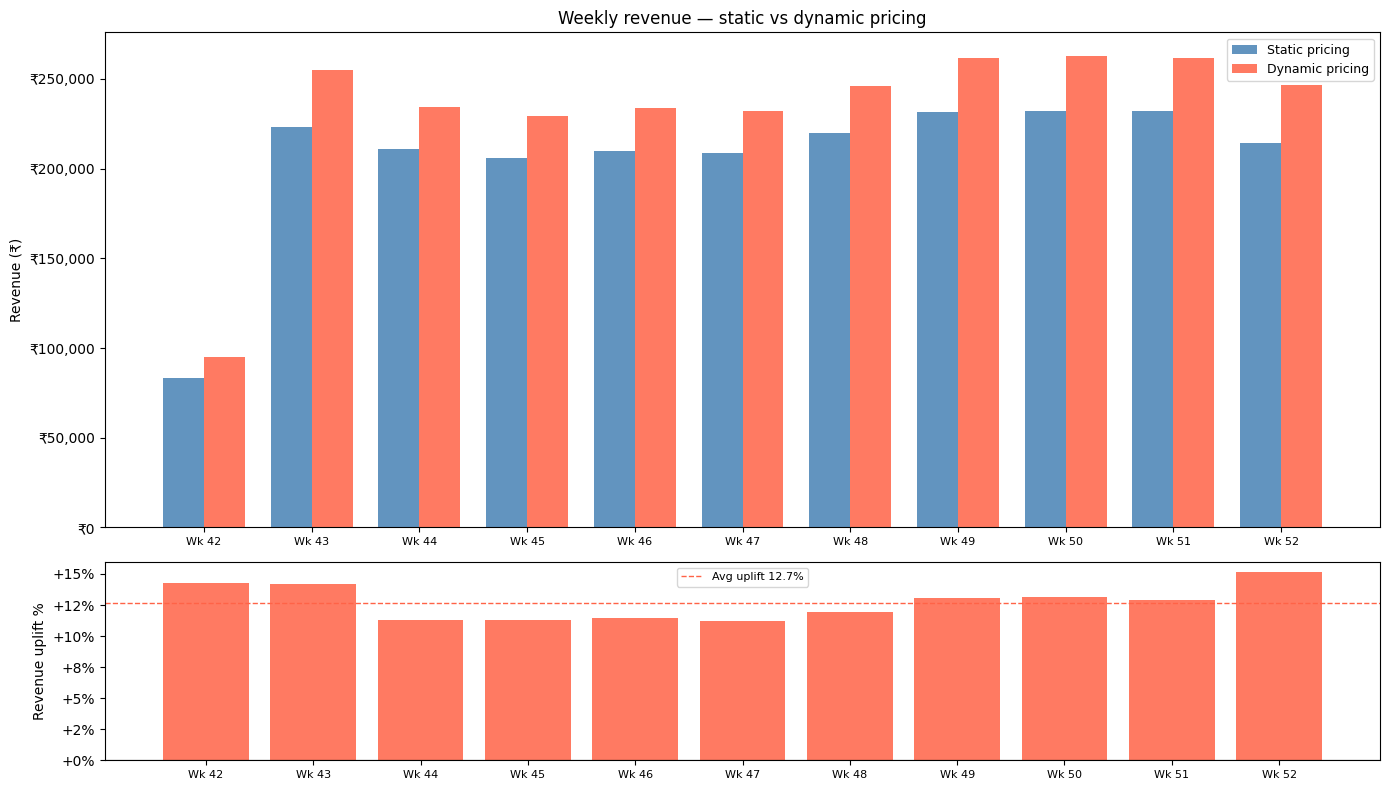

Top 3 weeks by revenue uplift:
 week  static_rev   dynamic_rev  uplift_pct
   52    214080.0 246591.192574   15.186469
   42     83160.0  95031.892105   14.275965
   43    223150.0 254751.612761   14.161601


In [2]:
weekly = df.groupby('week').agg(
    static_rev  = ('static_revenue',  'sum'),
    dynamic_rev = ('dynamic_revenue', 'sum'),
).reset_index()
weekly['uplift_pct'] = ((weekly['dynamic_rev'] - weekly['static_rev'])
                         / weekly['static_rev'] * 100)

fig, axes = plt.subplots(2, 1, figsize=(14, 8),
                          gridspec_kw={'height_ratios': [2.5, 1]})

# ── Top panel: revenue bars ──
x     = np.arange(len(weekly))
width = 0.38
ax    = axes[0]
bars1 = ax.bar(x - width/2, weekly['static_rev'],  width,
               label='Static pricing',  color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, weekly['dynamic_rev'], width,
               label='Dynamic pricing', color='tomato',    alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f"Wk {w}" for w in weekly['week']], fontsize=8)
ax.set_ylabel('Revenue (₹)', fontsize=10)
ax.set_title('Weekly revenue — static vs dynamic pricing', fontsize=12)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda v, _: f'₹{v:,.0f}'))
ax2 = axes[1]
colors = ['tomato' if v > 0 else 'steelblue'
          for v in weekly['uplift_pct']]
ax2.bar(x, weekly['uplift_pct'], color=colors, alpha=0.85)
ax2.axhline(0, color='black', lw=0.8)
ax2.axhline(UPLIFT_PCT, color='tomato', ls='--',
            lw=1, label=f'Avg uplift {UPLIFT_PCT:.1f}%')
ax2.set_xticks(x)
ax2.set_xticklabels([f"Wk {w}" for w in weekly['week']], fontsize=8)
ax2.set_ylabel('Revenue uplift %', fontsize=10)
ax2.legend(fontsize=8)
ax2.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda v, _: f'{v:+.0f}%'))
plt.tight_layout()
plt.savefig('../output/weekly_revenue_comparison.png', dpi=150)
plt.show()

print("Top 3 weeks by revenue uplift:")
top3 = weekly.nlargest(3, 'uplift_pct')[
    ['week','static_rev','dynamic_rev','uplift_pct']]
print(top3.to_string(index=False))

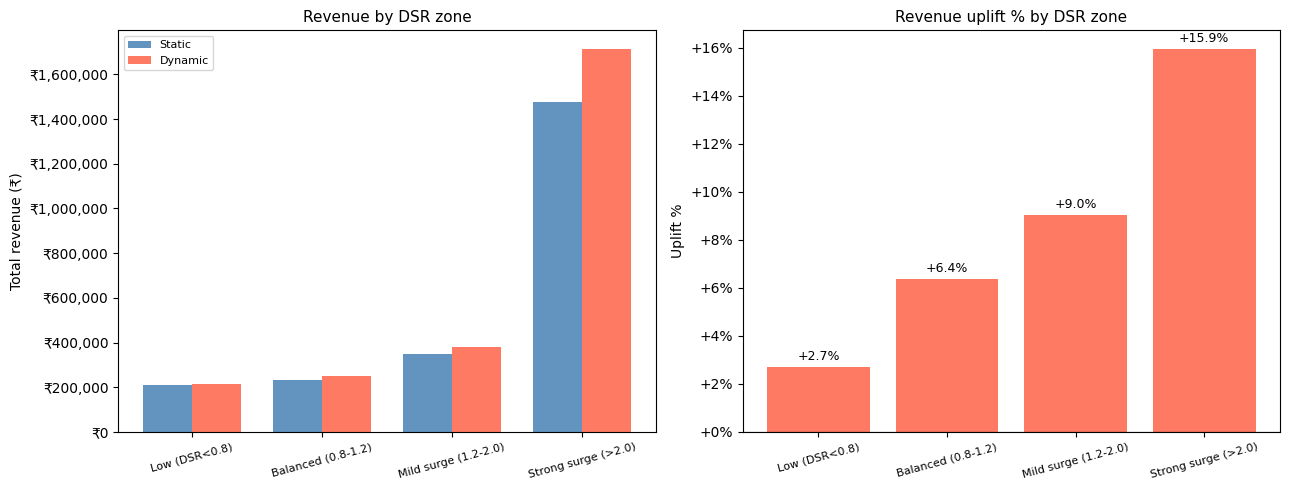


DSR zone breakdown:
          zone_label  hours  avg_dsr  avg_dynamic_price  avg_conversion  uplift_pct
       Low (DSR<0.8)    526 0.598318          11.013669       94.668074    2.709723
  Balanced (0.8-1.2)    302 0.974511          12.413179       87.281107    6.370535
Mild surge (1.2-2.0)    304 1.527165          13.666974       82.412146    9.038944
 Strong surge (>2.0)    582 3.632294          16.308797       72.579502   15.918820


In [3]:
zone_summary = df.groupby('dsr_zone').agg(
    hours        = ('timestamp',       'count'),
    static_rev   = ('static_revenue',  'sum'),
    dynamic_rev  = ('dynamic_revenue', 'sum'),
    avg_dsr      = ('DSR',             'mean'),
    avg_dynamic_price = ('smoothed_price', 'mean'),
    avg_conversion    = ('dynamic_demand', lambda x:
                          (x / df.loc[x.index, 'actual_demand']).mean() * 100)
).reset_index()

zone_summary['uplift_pct'] = (
    (zone_summary['dynamic_rev'] - zone_summary['static_rev'])
    / zone_summary['static_rev'] * 100
)
zone_summary['zone_label'] = zone_summary['dsr_zone'].str.split('_').str[1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: revenue by zone ──
x     = np.arange(len(zone_summary))
width = 0.38
ax    = axes[0]
ax.bar(x - width/2, zone_summary['static_rev'],
       width, label='Static',  color='steelblue', alpha=0.85)
ax.bar(x + width/2, zone_summary['dynamic_rev'],
       width, label='Dynamic', color='tomato',    alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(zone_summary['zone_label'],
                   fontsize=8, rotation=15)
ax.set_title('Revenue by DSR zone', fontsize=11)
ax.set_ylabel('Total revenue (₹)')
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'₹{v:,.0f}'))

# ── Right: uplift % by zone ──
ax2 = axes[1]
colors = ['tomato' if v > 0 else 'steelblue'
          for v in zone_summary['uplift_pct']]
bars = ax2.bar(x, zone_summary['uplift_pct'],
               color=colors, alpha=0.85)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(zone_summary['zone_label'],
                    fontsize=8, rotation=15)
ax2.set_title('Revenue uplift % by DSR zone', fontsize=11)
ax2.set_ylabel('Uplift %')
ax2.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda v, _: f'{v:+.0f}%'))

# Add value labels
for bar, val in zip(bars, zone_summary['uplift_pct']):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:+.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../output/dsr_zone_comparison.png', dpi=150)
plt.show()

print("\nDSR zone breakdown:")
print(zone_summary[['zone_label','hours','avg_dsr',
                     'avg_dynamic_price','avg_conversion',
                     'uplift_pct']].to_string(index=False))

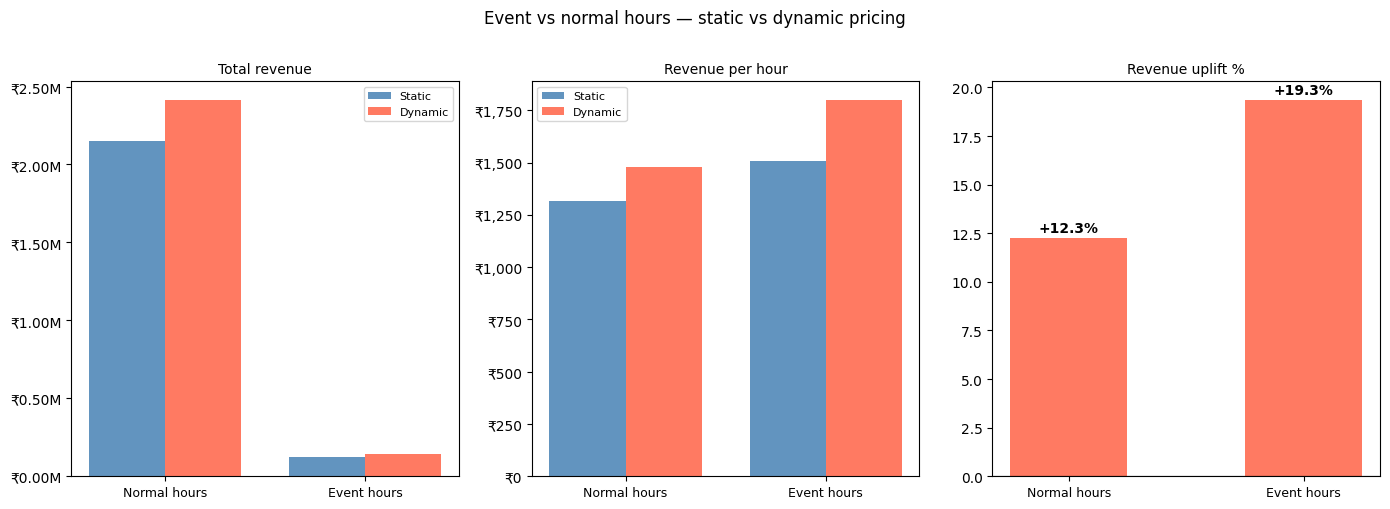


Event vs normal breakdown:
       label  hours  avg_dsr  avg_price  revenue_per_hour_static  revenue_per_hour_dynamic  uplift_pct
Normal hours   1633 1.801442  13.398726              1315.946111               1477.414135   12.270109
 Event hours     81 3.031063  16.152222              1506.666667               1798.179845   19.348220


In [4]:
event_summary = df.groupby('is_event').agg(
    hours          = ('timestamp',        'count'),
    static_rev     = ('static_revenue',   'sum'),
    dynamic_rev    = ('dynamic_revenue',  'sum'),
    avg_dsr        = ('DSR',              'mean'),
    avg_price      = ('smoothed_price',   'mean'),
    avg_actual_dem = ('actual_demand',    'mean'),
    avg_dynamic_dem= ('dynamic_demand',   'mean'),
).reset_index()

event_summary['uplift_pct'] = (
    (event_summary['dynamic_rev'] - event_summary['static_rev'])
    / event_summary['static_rev'] * 100
)
event_summary['revenue_per_hour_static']  = (event_summary['static_rev']
                                              / event_summary['hours'])
event_summary['revenue_per_hour_dynamic'] = (event_summary['dynamic_rev']
                                              / event_summary['hours'])
event_summary['label'] = event_summary['is_event'].map(
    {0: 'Normal hours', 1: 'Event hours'})

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# ── Panel 1: total revenue ──
ax = axes[0]
x  = np.arange(2); width = 0.38
ax.bar(x - width/2, event_summary['static_rev'],
       width, label='Static',  color='steelblue', alpha=0.85)
ax.bar(x + width/2, event_summary['dynamic_rev'],
       width, label='Dynamic', color='tomato',    alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(event_summary['label'], fontsize=9)
ax.set_title('Total revenue', fontsize=10)
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda v, _: f'₹{v/1e6:.2f}M'))

# ── Panel 2: revenue per hour ──
ax2 = axes[1]
ax2.bar(x - width/2, event_summary['revenue_per_hour_static'],
        width, label='Static',  color='steelblue', alpha=0.85)
ax2.bar(x + width/2, event_summary['revenue_per_hour_dynamic'],
        width, label='Dynamic', color='tomato',    alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(event_summary['label'], fontsize=9)
ax2.set_title('Revenue per hour', fontsize=10)
ax2.legend(fontsize=8)
ax2.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda v, _: f'₹{v:,.0f}'))

# ── Panel 3: uplift % ──
ax3 = axes[2]
colors = ['tomato' if v > 0 else 'steelblue'
          for v in event_summary['uplift_pct']]
bars = ax3.bar(x, event_summary['uplift_pct'],
               color=colors, alpha=0.85, width=0.5)
ax3.axhline(0, color='black', lw=0.8)
ax3.set_xticks(x)
ax3.set_xticklabels(event_summary['label'], fontsize=9)
ax3.set_title('Revenue uplift %', fontsize=10)
for bar, val in zip(bars, event_summary['uplift_pct']):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:+.1f}%', ha='center', fontsize=10,
             fontweight='bold')

plt.suptitle('Event vs normal hours — static vs dynamic pricing',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('../output/event_vs_normal_comparison.png', dpi=150)
plt.show()

print("\nEvent vs normal breakdown:")
cols = ['label','hours','avg_dsr','avg_price',
        'revenue_per_hour_static','revenue_per_hour_dynamic','uplift_pct']
print(event_summary[cols].to_string(index=False))

In [5]:
import os
os.makedirs('../output', exist_ok=True)

# ── Annualised projections ──
# Test period is Oct 20 – Dec 31 = ~73 days
test_days    = (df['timestamp'].max() - df['timestamp'].min()).days + 1
annual_scale = 365 / test_days

annual_static_rev  = STATIC_REVENUE  * annual_scale
annual_dynamic_rev = DYNAMIC_REVENUE * annual_scale
annual_uplift_rev  = annual_dynamic_rev - annual_static_rev

# ── Conversion stats ──
avg_conversion = (df['dynamic_demand'] /
                  df['actual_demand']).mean() * 100
peak_price     = df['smoothed_price'].max()
floor_hours    = (df['multiplier'] == 0.8).sum()
ceil_hours     = (df['multiplier'] == 2.5).sum()

# ── Print full business summary ──
print("=" * 55)
print("  PHASE 4 — BUSINESS IMPACT SUMMARY")
print("=" * 55)
print(f"\n  TEST PERIOD ({test_days} days: Oct 20 – Dec 31)")
print(f"  {'Static revenue':<30}: ₹{STATIC_REVENUE:>12,.0f}")
print(f"  {'Dynamic revenue':<30}: ₹{DYNAMIC_REVENUE:>12,.0f}")
print(f"  {'Revenue uplift':<30}: {UPLIFT_PCT:>+11.1f}%")
print(f"  {'Additional revenue':<30}: "
      f"₹{DYNAMIC_REVENUE-STATIC_REVENUE:>12,.0f}")
print()
print(f"  ANNUALISED PROJECTION")
print(f"  {'Annual static revenue':<30}: ₹{annual_static_rev:>12,.0f}")
print(f"  {'Annual dynamic revenue':<30}: ₹{annual_dynamic_rev:>12,.0f}")
print(f"  {'Annual revenue uplift':<30}: "
      f"₹{annual_uplift_rev:>12,.0f}")
print()
print(f"  PRICING STATS")
print(f"  {'Avg dynamic price':<30}: ₹{df['smoothed_price'].mean():>11.2f}")
print(f"  {'Price range':<30}: "
      f"₹{df['smoothed_price'].min():.2f} – "
      f"₹{df['smoothed_price'].max():.2f}")
print(f"  {'Hours at floor (₹8)':<30}: "
      f"{floor_hours:>8} ({floor_hours/len(df)*100:.1f}%)")
print(f"  {'Hours at ceiling':<30}: "
      f"{ceil_hours:>8} ({ceil_hours/len(df)*100:.1f}%)")
print()
print(f"  CONVERSION")
print(f"  {'Avg conversion rate':<30}: {avg_conversion:>11.1f}%")
print(f"  {'Demand retained':<30}: "
      f"{avg_conversion:.1f}% of baseline demand")
print(f"  {'Demand trade-off':<30}: "
      f"{100-avg_conversion:.1f}% lost to price sensitivity")
print()
print(f"  FORECASTING MODEL (Phase 2)")
print(f"  {'Baseline MAPE':<30}: {'16.7%':>12}")
print(f"  {'Model MAPE':<30}: {'3.1%':>12}")
print(f"  {'Improvement':<30}: {'13.6pp':>12}")
print(f"  {'Prediction coverage':<30}: {'75.0%':>12}")
print("=" * 55)

# ── Save final output ──
df.to_csv('../output/phase4_full_simulation.csv', index=False)
print(f"\nSaved: ../output/phase4_full_simulation.csv")
print(f"       ../output/weekly_revenue_comparison.png")
print(f"       ../output/dsr_zone_comparison.png")
print(f"       ../output/event_vs_normal_comparison.png")

  PHASE 4 — BUSINESS IMPACT SUMMARY

  TEST PERIOD (72 days: Oct 20 – Dec 31)
  Static revenue                : ₹   2,270,980
  Dynamic revenue               : ₹   2,558,270
  Revenue uplift                :       +12.7%
  Additional revenue            : ₹     287,290

  ANNUALISED PROJECTION
  Annual static revenue         : ₹  11,512,607
  Annual dynamic revenue        : ₹  12,969,007
  Annual revenue uplift         : ₹   1,456,400

  PRICING STATS
  Avg dynamic price             : ₹      13.53
  Price range                   : ₹8.62 – ₹23.21
  Hours at floor (₹8)           :      301 (17.6%)
  Hours at ceiling              :      172 (10.0%)

  CONVERSION
  Avg conversion rate           :        83.7%
  Demand retained               : 83.7% of baseline demand
  Demand trade-off              : 16.3% lost to price sensitivity

  FORECASTING MODEL (Phase 2)
  Baseline MAPE                 :        16.7%
  Model MAPE                    :         3.1%
  Improvement                   :   